In [1]:
import json
import sys
from pathlib import Path

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "llmr_updated_arch").exists():
    repo_root = repo_root.parent

for rel_path in (
    "llmr_updated_arch/src",
    "krrood/src",
    "pycram/src",
    "semantic_digital_twin/src",
    "uniworld/src",
):
    src_path = repo_root / rel_path
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

from dotenv import load_dotenv
from krrood.entity_query_language.query.match import Match
from pycram.datastructures.grasp import GraspDescription
from pycram.robot_plans.actions.core.pick_up import PickUpAction
from semantic_digital_twin.world_description.world_entity import Body
from uniworld import load_pr2_apartment_world

from llmr_updated_arch import LLMBackend
from llmr_updated_arch.generation.flanagan import FlanaganReasoner
from llmr_updated_arch.generation.framenet import FrameNetReasoner
from llmr_updated_arch.hypotheses import BuildOrchestrator
from llmr_updated_arch.integrations.langchain.provider import LLMProvider, make_llm

## World And Model Setup

In [2]:
for env_path in (
    repo_root / "llmr" / ".env",
    repo_root / "llmr_updated_arch" / ".env",
    repo_root / ".env",
):
    if env_path.exists():
        load_dotenv(env_path, override=False)

world, robot_view, context = load_pr2_apartment_world()
context.evaluate_conditions = False

symbol_type = Body

llm = make_llm(LLMProvider.OPENAI, model="gpt-4o-mini", temperature=0.0)
print("LLM ready:", getattr(llm, "model_name", llm))

Unknown attribute "type" in /robot[@name='pr2']/link[@name='base_laser_link']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='wide_stereo_optical_frame']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='narrow_stereo_optical_frame']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='laser_tilt_link']
Unknown tag "material" in /robot[@name='pr2']/link[@name='l_force_torque_link']/collision[1]
Unknown tag "material" in /robot[@name='apartment']/link[@name='coffe_machine']/collision[1]


LLM ready: gpt-4o-mini


## Backend And Match Helpers

In [3]:
def fresh_pickup_match():
    return Match(PickUpAction)(
        object_designator=...,
        arm=...,
        grasp_description=Match(GraspDescription)(
            approach_direction=...,
            vertical_alignment=...,
            manipulator=...,
        ),
    )


def print_pickup_action(action_instance):
    print("Action type:", type(action_instance).__name__)
    print("Object     :", action_instance.object_designator)
    print("Arm        :", action_instance.arm)
    print("Grasp      :", action_instance.grasp_description)


orchestrator = BuildOrchestrator.with_default_builders()
graph = orchestrator.graph


def run_instruction(instruction: str):
    backend = LLMBackend(
        llm=llm,
        symbol_type=symbol_type,
        instruction=instruction,
        strict_required=True,
        reasoners=[
            FrameNetReasoner(llm=llm),
            FlanaganReasoner(llm=llm),
        ],
        sg_model_orchestrator=orchestrator,
    )
    action = next(iter(backend.evaluate(fresh_pickup_match())))
    return action, backend

## Resolve One Instruction

In [4]:
INSTRUCTION = "pick up the milk from the table"

action, backend = run_instruction(INSTRUCTION)
print_pickup_action(action)

Action type: PickUpAction
Object     : Body(name=PrefixedName('None/milk.stl'), id=UUID('84efd790-448e-42c2-8ff8-5d83eef7e5f7'), index=219)
Arm        : RIGHT
Grasp      : GraspDescription(approach_direction=<ApproachDirection.FRONT: (<AxisIdentifier.X: (1, 0, 0)>, -1)>, vertical_alignment=<VerticalAlignment.TOP: (<AxisIdentifier.Z: (0, 0, 1)>, -1)>, manipulator=ParallelGripper(name=PrefixedName('pr2/right_gripper'), id=UUID('20ca8008-1a57-49eb-82bc-23a7bed56fc5'), root=Body(name=PrefixedName('pr2/r_gripper_palm_link'), id=UUID('73e92635-f1f3-483c-8058-6034639b3bb2'), index=62), _robot=PR2(neck=Neck(name=PrefixedName('pr2/neck'), id=UUID('d9361018-b73c-4637-8e33-b460637bbaf9'), root=Body(name=PrefixedName('pr2/head_pan_link'), id=UUID('1b068695-befb-4d75-b758-28f3b484c6e7'), index=21), _robot=..., joint_states=[], tip=Body(name=PrefixedName('pr2/head_tilt_link'), id=UUID('71c15192-b110-4059-8a55-5b492e395e33'), index=22), manipulator=None, sensors=[Camera(name=PrefixedName('pr2/wide_st

## Inspect Semantic Outputs

In [5]:
semantics = backend.semantics.model_dump(mode="json")
print(json.dumps(semantics, indent=2, default=repr))

{
  "action_type": "PickUpAction",
  "instruction": "pick up the milk from the table",
  "classification": null,
  "slot_filling": {
    "action_type": "PickUpAction",
    "slots": [
      {
        "field_name": "object_designator",
        "value": null,
        "entity_description": {
          "name": "milk.stl",
          "semantic_type": "Milk",
          "spatial_context": "on the table",
          "attributes": null
        },
        "reasoning": "The instruction specifies picking up 'the milk', which corresponds to the object 'milk.stl' identified in the scene."
      },
      {
        "field_name": "arm",
        "value": "RIGHT",
        "entity_description": null,
        "reasoning": "The right arm is chosen as it is commonly used for actions requiring precision, such as picking up an object."
      },
      {
        "field_name": "grasp_description.approach_direction",
        "value": "FRONT",
        "entity_description": null,
        "reasoning": "Approaching from 

## Inspect Hypothesis Projection

In [6]:
print("Projection result:", backend.last_build_result)
print("FrameNet nodes:", len(graph.nodes_from_reasoner("framenet_reasoner")))
print("Flanagan nodes:", len(graph.nodes_from_reasoner("flanagan_reasoner")))
print("Total hypothesis nodes:", len(list(graph)))

Projection result: BuildResult(roots=[FrameClaim(id='framenet_reasoner:b9f2000eed7848d7acedea267c8d581e:node:frame', meta=HypothesisMeta(source_reasoner='framenet_reasoner', status=<ClaimStatus.HYPOTHESIS: 'hypothesis'>, grounding=<GroundingState.TEXT_ONLY: 'text_only'>, confidence=None, run_id='b9f2000eed7848d7acedea267c8d581e', prompt_version='framenet_v1', model_name='gpt-4o-mini', created_at=datetime.datetime(2026, 5, 12, 11, 34, 15, 387429, tzinfo=datetime.timezone.utc)), frame='Getting', lexical_unit='pick_up.v', framenet_label='picking_up_object', action_type='PickUpAction', instruction_text='pick up the milk from the table'), PlanClaim(id='flanagan_reasoner:b808d349745c4403b6fadcaaa3c13c56:node:plan', meta=HypothesisMeta(source_reasoner='flanagan_reasoner', status=<ClaimStatus.HYPOTHESIS: 'hypothesis'>, grounding=<GroundingState.TEXT_ONLY: 'text_only'>, confidence=None, run_id='b808d349745c4403b6fadcaaa3c13c56', prompt_version='flanagan_v1', model_name='gpt-4o-mini', created_at

Hypothesis graph nodes: 51
DOT lines: 108


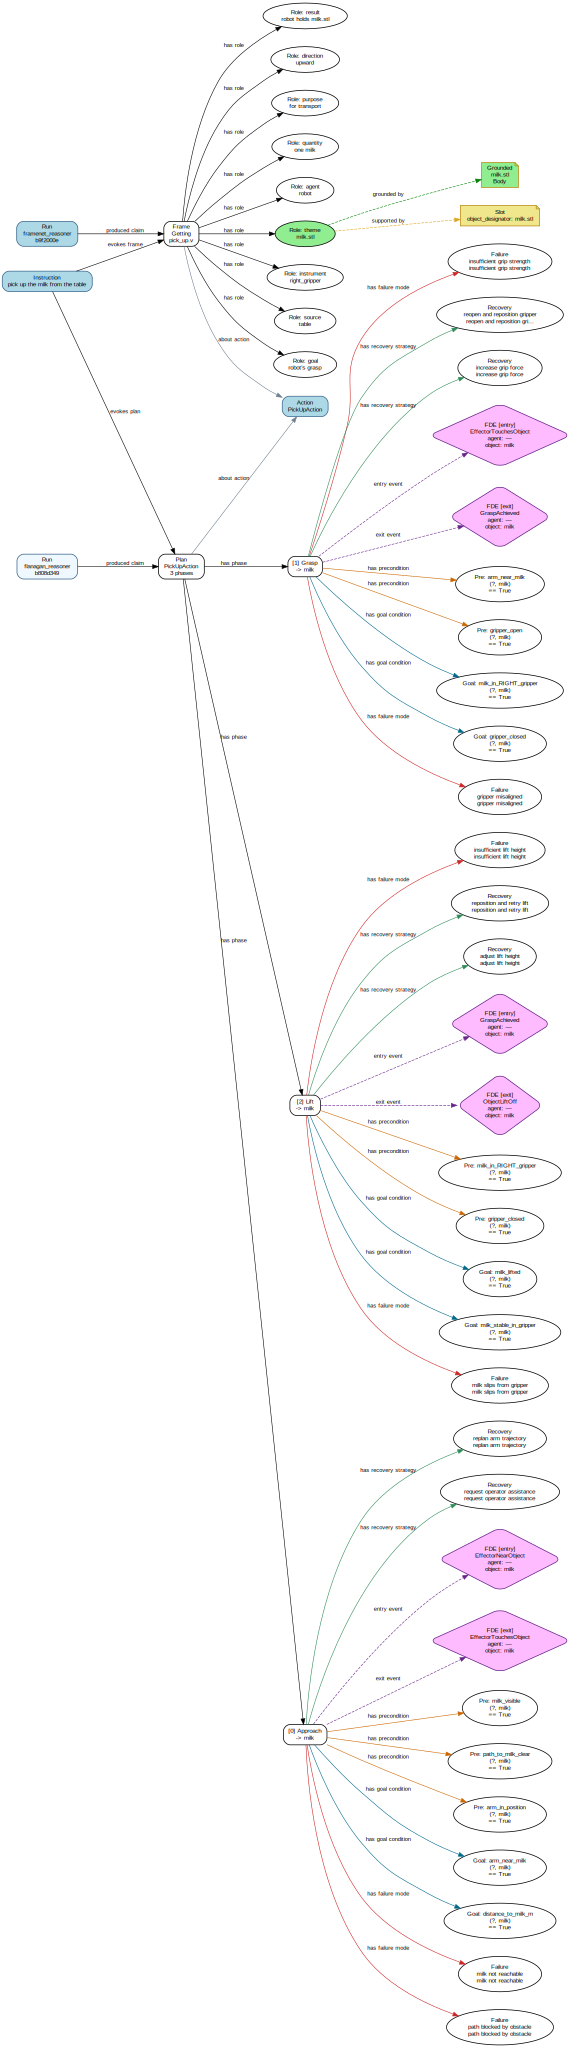

In [7]:
from graphviz import Source
from IPython.display import display
from llmr_updated_arch.hypotheses.adapters import to_dot, render_graph

print(f"Hypothesis graph nodes: {len(list(graph))}")
dot = to_dot(graph)
print(f"DOT lines: {len(dot.splitlines())}")

try:
    src = Source(dot, format="svg")
    display(src)
    output_path = repo_root / "llmr_updated_arch" / "notebooks" / "hypo_graph"
    src.render(str(output_path), cleanup=True)
except Exception as exc:
    print(f"Graphviz display failed: {type(exc).__name__}: {exc}")
    print(dot)


In [9]:
type(action)

pycram.robot_plans.actions.core.pick_up.PickUpAction

In [14]:
action.object_designator

Body(name=PrefixedName('None/milk.stl'), id=UUID('84efd790-448e-42c2-8ff8-5d83eef7e5f7'), index=219)

In [19]:
backend.semantics.__dict__.keys()

dict_keys(['action_type', 'instruction', 'classification', 'slot_filling', 'motion_phases', 'frames', 'preconditions', 'postconditions', 'affordances', 'extra', 'artifacts'])

In [24]:
backend.semantics.__dict__['motion_phases'].model_dump()

{'instruction': 'pick up the milk from the table',
 'phases': [{'phase': 'Approach',
   'target_object': 'milk',
   'description': 'move to milk on table',
   'symbol': '->[ robot approachs milk]',
   'goal_state': {'arm_near_milk': True, 'distance_to_milk_m': 0.2},
   'preconditions': {'milk_visible': True,
    'path_to_milk_clear': True,
    'arm_in_position': True},
   'force_dynamics': {},
   'sensory_feedback': {'camera_milk_detected': True,
    'RIGHT_arm_joint_position': 'pre_grasp'},
   'failure_and_recovery': {'possible_failures': ['milk not reachable',
     'path blocked by obstacle'],
    'recovery_strategies': ['replan arm trajectory',
     'request operator assistance']},
   'temporal_constraints': {'max_duration_sec': 3.0, 'urgency': 'medium'}},
  {'phase': 'Grasp',
   'target_object': 'milk',
   'description': 'grip the milk container',
   'symbol': '->[ robot grasps milk]',
   'goal_state': {'milk_in_RIGHT_gripper': True, 'gripper_closed': True},
   'preconditions': {'a